In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
from utils import quality_metrics

# Allow more columns to be displayed
pd.set_option("display.max_columns", None)

import logging
logging.basicConfig(level=logging.WARNING)

In [3]:
!which python

/Users/klemenkubelj/miniconda3/envs/cvar-masters/bin/python


In [23]:
df = pd.read_csv(os.path.join("../data/vloge_processed_2025-05-10.csv"))
print("Original shape:", df.shape)

# df["relative_damage"] = df["SkupnaSkoda"] / df["Vrednost"]
df["relative_damage"] = df["OdstPoskodovanostiObjekta"] / 100
df = df[df["relative_damage"]<=1]
print("After filtering:", df.shape)

Original shape: (20040, 17)
After filtering: (6440, 18)


(0.0, 300.0)

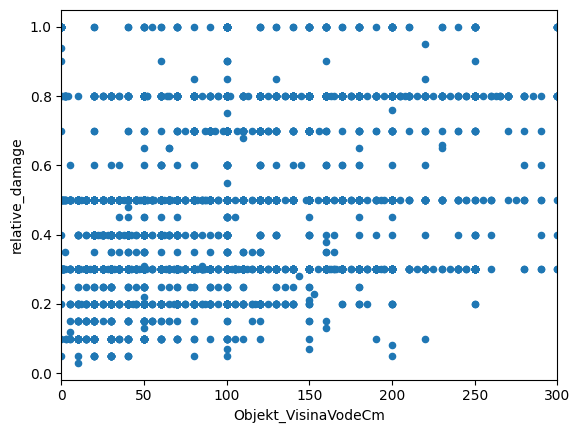

In [24]:

df.plot(x="Objekt_VisinaVodeCm", y="relative_damage", kind="scatter")
plt.xlim(0, 300)

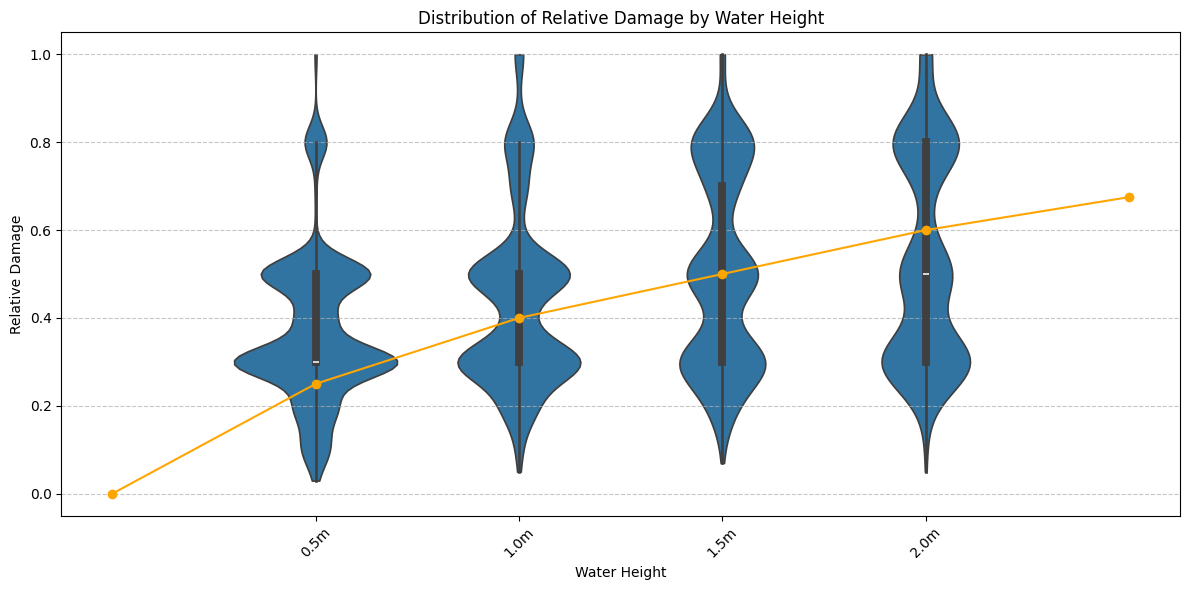

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df["Objekt_VisinaVodeM"] = df["Objekt_VisinaVodeCm"]/100
# Create water height buckets (every 50cm up to 200cm)
bucket_edges = np.arange(0, 2.01, 0.5)
df["water_height_bucket"] = pd.cut(
    df["Objekt_VisinaVodeM"], 
    bins=bucket_edges,
    labels=[f"{i}-{i+0.5}m" for i in np.arange(0, 2, 0.5)]
)

# Create the violin plot
plt.figure(figsize=(12, 6))

# Plot violins
sns.violinplot(
    data=df,
    x="water_height_bucket",
    y="relative_damage",
    cut=0  # limit the violin plot to actual data range
)

# Adjust x-axis to show ticks at the upper bounds of each bucket
plt.gca().set_xticks(range(len(bucket_edges)-1))
plt.gca().set_xticklabels([f"{x}m" for x in bucket_edges[1:]])

# Customize the plot
plt.title("Distribution of Relative Damage by Water Height")
plt.xlabel("Water Height")
plt.ylabel("Relative Damage")
plt.xticks(rotation=45)

# Add grid for better readability
plt.grid(True, axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

flood_depths = [
    0,
    0.5,
    1,
    1.5,
    2,
    2.5,
    # 3,
    # 4,
    # 5,
    # 6
]
damage_fractions = [
    0.00,
    0.25,
    0.40,
    0.50,
    0.60,
    0.675,
    # 0.75,
    # 0.85,
    # 0.95,
    # 1.00
]
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

def get_damage_fraction(depth):
    """
    Get damage fraction for a given flood depth using polynomial interpolation.
    For depths outside the range, we clamp the values to [0, 1].
    
    Args:
        depth (float): Flood depth in meters
        
    Returns:
        float: Damage fraction between 0 and 1
    """
    # Create interpolation function
    f = interp1d(flood_depths, damage_fractions, kind="linear", bounds_error=False, fill_value=(0, 1))
    return float(f(depth))

# Create points for smooth curve visualization
depths_smooth = np.linspace(0, 2.5, 100)
damage_smooth = [get_damage_fraction(d) for d in depths_smooth]

# # FIX
# positions = range(len(bucket_edges[1:]))  # [0, 1, 2, 3, 4]
# bucket_values = bucket_edges[1:]  # [0.5, 1.0, 1.5, 2.0, 2.5]
# plt.xticks(positions, [f"{x}m" for x in bucket_values], rotation=45)
# new_positions = dict(zip(bucket_values, positions))

# Plot the data and fitted curve
# plt.figure(figsize=(10, 6))
plt.plot([(i - 0.5)*2 for i in flood_depths], damage_fractions, "o", label="Data points", color="orange")
plt.plot([(i - 0.5)*2 for i in depths_smooth], damage_smooth, "-", label="Cubic interpolation", color="orange")

plt.show()